In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import umap
from IPython.display import Image, display

working_dir = Path.cwd().resolve()
PROJECT_ROOT = working_dir.parent if working_dir.name == "figures" else working_dir
FIGURES_DIR = PROJECT_ROOT / "figures/outputs"
FIGUTIL_DIR = PROJECT_ROOT / "figures/figutil"
FIGDATA_DIR = PROJECT_ROOT / "figures/figdata/token_umap"
FIGDATA_DIR.mkdir(parents=True, exist_ok=True)

for module_dir in (PROJECT_ROOT, FIGUTIL_DIR):
    if str(module_dir) not in sys.path:
        sys.path.insert(0, str(module_dir))

from plot_umap import (
    DEFAULT_CHECKPOINT,
    DEFAULT_FREQUENCY_DATA,
    DEFAULT_LABELS,
    DEFAULT_NOTEBOOK,
    MEDICATION_TOKEN_IDS,
    compact_inset_configs,
    configure_exact_legacy_font,
    exact_plot_functions,
    load_frequencies,
    load_metadata,
)
from utils import load_checkpoint

CHECKPOINT_PATH = DEFAULT_CHECKPOINT
LABELS_PATH = DEFAULT_LABELS
FREQUENCY_DATA_PATH = DEFAULT_FREQUENCY_DATA
LEGACY_NOTEBOOK_PATH = DEFAULT_NOTEBOOK

for input_path in (
    CHECKPOINT_PATH,
    LABELS_PATH,
    FREQUENCY_DATA_PATH,
    LEGACY_NOTEBOOK_PATH,
):
    if not input_path.is_file():
        raise FileNotFoundError(input_path)

print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Figure data: {FIGDATA_DIR}")
print("Figure export: transparent PNG/PDF with tight bounds")

/home/hsh/miniconda3/envs/hsh/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/hsh/GPT-Disease-Drug-Prediction
Checkpoint: /home/hsh/GPT-Disease-Drug-Prediction/best_ckpt.pt
Figure data: /home/hsh/GPT-Disease-Drug-Prediction/figures/figdata/token_umap
Figure export: transparent PNG/PDF with tight bounds


In [2]:
font_path, font_name = configure_exact_legacy_font()
token_meta, legend_info = load_metadata(LABELS_PATH)
token_counts, frequency_rows = load_frequencies(FREQUENCY_DATA_PATH)
draw_main, draw_clean, renderer_hashes = exact_plot_functions(LEGACY_NOTEBOOK_PATH)

print(f"Metadata tokens: {len(token_meta):,}")
print(f"Training rows used for frequency: {frequency_rows:,}")
print(f"Font: {font_name}")

Metadata tokens: 1,267
Training rows used for frequency: 13,439,034
Font: Helvetica


In [3]:
model, checkpoint = load_checkpoint(CHECKPOINT_PATH, "cpu")
valid_token_ids = sorted(
    token_id
    for token_id in token_meta
    if 0 <= token_id < model.config.vocab_size
)

embeddings = (
    model.token.weight.detach().cpu().numpy()[valid_token_ids]
    .astype(np.float32, copy=True)
)

assert embeddings.shape == (1267, 384), embeddings.shape
assert np.isfinite(embeddings).all()

print(f"Checkpoint step: {int(checkpoint['step']):,}")
print(f"Token embedding matrix: {embeddings.shape}")

Checkpoint step: 10,500
Token embedding matrix: (1267, 384)


In [4]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.02,
    metric="cosine",
    random_state=42,
    n_jobs=1,
)
coordinates = reducer.fit_transform(embeddings).astype(np.float32, copy=False)
# Rotate 90° counter-clockwise: (x, y) -> (-y, x)
coordinates = np.column_stack((-coordinates[:, 1], coordinates[:, 0])).astype(
    np.float32, copy=False
)
assert coordinates.shape == (1267, 2)
assert np.isfinite(coordinates).all()

coordinate_table = pd.DataFrame(
    {
        "x": coordinates[:, 0],
        "y": coordinates[:, 1],
        "token_id": valid_token_ids,
        "name": [token_meta[token_id]["name"] for token_id in valid_token_ids],
        "chapter_short": [
            token_meta[token_id]["chapter_short"] for token_id in valid_token_ids
        ],
        "count": [token_counts.get(token_id, 0) for token_id in valid_token_ids],
    }
)

coordinates_path = FIGDATA_DIR / "umap_coordinates.csv"
coordinate_table.to_csv(coordinates_path, index=False)
print(f"Saved coordinates: {coordinates_path}")

Saved coordinates: /home/hsh/GPT-Disease-Drug-Prediction/figures/figdata/token_umap/umap_coordinates.csv


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


[INFO] Rendering UMAP scatter plot...
[INFO] Kept 759/1267 tokens with count >= 50


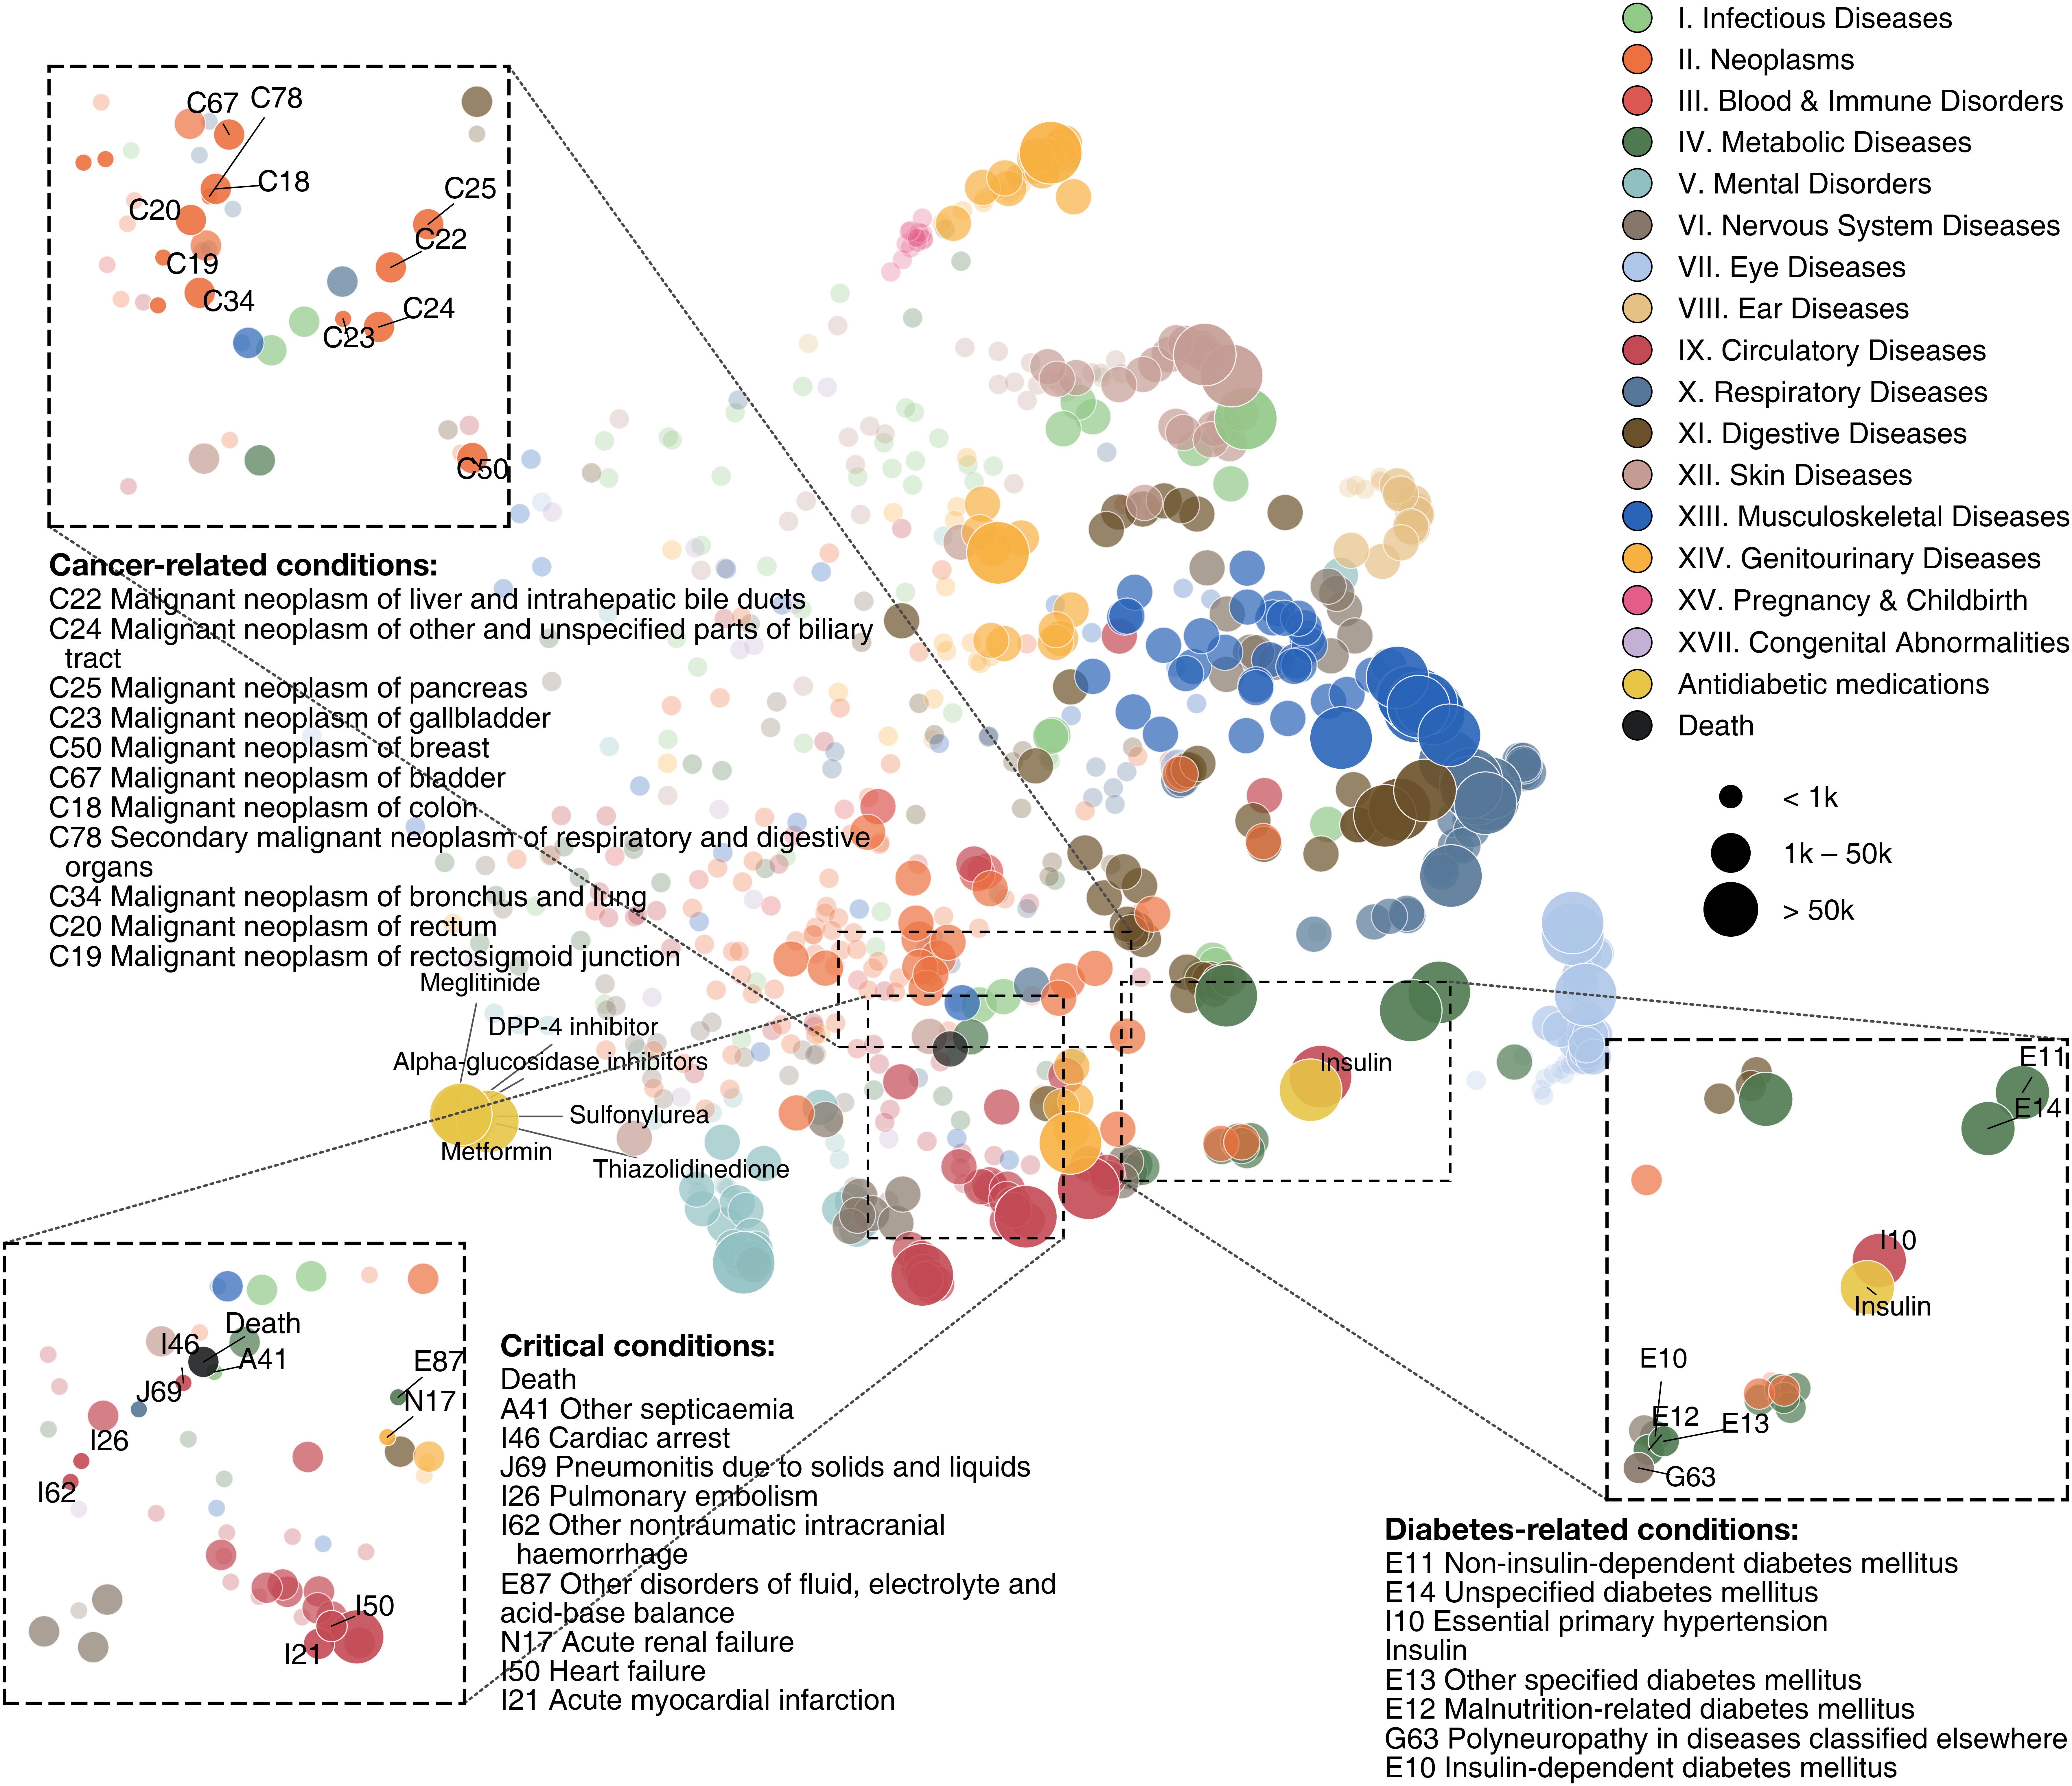

Saved tight transparent figure: /home/hsh/GPT-Disease-Drug-Prediction/figures/outputs/umap.png
Saved vector figure: /home/hsh/GPT-Disease-Drug-Prediction/figures/outputs/umap.pdf
Visible-content crop: {'alpha_bbox_in_probe_pixels': [1379, 575, 8524, 6733], 'probe_size_pixels': [9080, 7221], 'content_bbox_inches': [np.float64(1.5792390969162993), np.float64(-0.7597327239994458), np.float64(9.538215418502201), np.float64(6.103058025204266)], 'pad_inches': 0.01}


In [5]:
# Draw the finalized layout defined in figures/figutil/plot_umap.py.
import importlib
from io import BytesIO
from PIL import Image as PILImage
import plot_umap as plot_umap_module

# Adjust this single value to change the disease/event display threshold.
MIN_EVENT_COUNT = 50

plot_umap_module = importlib.reload(plot_umap_module)
main_figure, renderer_hashes = plot_umap_module.draw_publication_umap(
    coordinates,
    valid_token_ids,
    token_meta,
    token_counts,
    legend_info,
    notebook_path=LEGACY_NOTEBOOK_PATH,
    min_event_count=MIN_EVENT_COUNT,
)

# Save tightly cropped publication files with transparent backgrounds.
UMAP_PNG = FIGURES_DIR / "umap.png"
UMAP_PDF = FIGURES_DIR / "umap.pdf"
crop_qc = plot_umap_module.save_transparent_content_bbox(
    main_figure, UMAP_PNG, UMAP_PDF, dpi=900, pad_inches=0.01
)
plt.close(main_figure)

# Display the same tight export on white inside Jupyter only.
with PILImage.open(UMAP_PNG).convert("RGBA") as rgba:
    white_preview = PILImage.new("RGBA", rgba.size, "white")
    white_preview.alpha_composite(rgba)
    preview_buffer = BytesIO()
    white_preview.convert("RGB").save(preview_buffer, format="PNG")
display(Image(data=preview_buffer.getvalue()))
print(f"Saved tight transparent figure: {UMAP_PNG}")
print(f"Saved vector figure: {UMAP_PDF}")
print(f"Visible-content crop: {crop_qc}")

In [6]:
# CLEAN_MIN_EVENT_COUNT = 100
# clean_figure = draw_clean(
#     coordinates,
#     valid_token_ids,
#     token_meta,
#     token_counts,
#     figsize=(5, 5),
#     min_event_count=CLEAN_MIN_EVENT_COUNT,
# )

# # Figure export is intentionally disabled until the final figure is approved.
# # clean_figure.savefig(FIGURES_DIR / "umap_clean.png", dpi=900, transparent=True, pad_inches=0.0)
# # clean_figure.savefig(FIGURES_DIR / "umap_clean.pdf", transparent=True, pad_inches=0.0)
# display(clean_figure)
# plt.close(clean_figure)